# WYP vs Random Analysis
Load evaluation results, plot overlapping reward histograms, and report SCP convergence counts.

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

def find_root_path(path: str, word: str) -> str:
    parts = path.split(word, 1)
    return parts[0] + word if len(parts) > 1 else path

root_folder = Path(find_root_path(str(Path.cwd()), "art_lang"))
out_dir = root_folder / "rpod" / "rages" / "out" 

npz_path1 = out_dir / "wyp_vs_random_unweighted_test.npz"
npz_path2 = out_dir / "wyp_vs_random_weighted_test.npz"

npz_paths = {
    "eval_unweighted": npz_path1,
    "eval_weighted": npz_path2,
}

datasets = {}
for tag, path in npz_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file for {tag}: {path}")
    print(f"Loading [{tag}]: {path}")
    ws = np.load(path, allow_pickle=True)
    datasets[tag] = ws
    print(f"[{tag}] keys:", ws.files)

# Keep a default handle for downstream cells.
ws = datasets["eval_unweighted"]


Loading [eval_unweighted]: /home/yuji/github/art_lang/rpod/rages/out/wyp_vs_random_unweighted_test.npz
[eval_unweighted] keys: ['case_id', 'dataset_idx', 'scenario_id', 'seed_scenario', 'policy', 'start_domain', 'target_domains', 'b_seq', 'b_seq_text', 'tof_steps', 'reward_model', 'reward_rand', 'status_model_cvx', 'status_model_scp', 'status_rand_cvx', 'status_rand_scp', 'traj_domain_correct_model', 'traj_domain_correct_rand', 'traj_domain_correct_model_by_margin', 'traj_domain_correct_rand_by_margin', 'i_infeas_model_cvx', 'i_infeas_model_scp', 'i_infeas_rand_cvx', 'i_infeas_rand_scp', 'i_rand_invalid', 'num_cases_requested', 'm_scenarios_requested', 'num_rows', 'skipped_no_domain', 'skipped_no_scenario', 'seed', 'val_ratio', 'num_process', 'device', 'error_margin']
Loading [eval_weighted]: /home/yuji/github/art_lang/rpod/rages/out/wyp_vs_random_weighted_test.npz
[eval_weighted] keys: ['case_id', 'dataset_idx', 'scenario_id', 'seed_scenario', 'policy', 'start_domain', 'target_domains

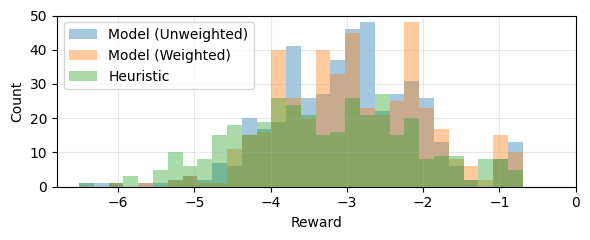

In [2]:
rewards = {}

# unweighted 
reward_model_u = np.asarray(datasets["eval_unweighted"]["reward_model"], dtype=float)
rm_u = reward_model_u[np.isfinite(reward_model_u)]
reward_rand_u = np.asarray(datasets["eval_unweighted"]["reward_rand"], dtype=float)
rr_u = reward_rand_u[np.isfinite(reward_rand_u)]

# weighted 
reward_model_w = np.asarray(datasets["eval_weighted"]["reward_model"], dtype=float)
rm_w = reward_model_w[np.isfinite(reward_model_w)]

rewards["Model (Unweighted)"] = rm_u
rewards["Model (Weighted)"] = rm_w
rewards["Heuristic"] = rr_u


combined = np.concatenate([rm_u, rr_u, rm_w])
if combined.size == 0:
    raise ValueError("No finite reward values found in either file.")

bins = np.histogram_bin_edges(combined, bins=30)

fig = plt.figure(figsize=(6, 2.5))
ax = fig.add_subplot(1, 1, 1)
for label, values in rewards.items():
    if values.size > 0:
        ax.hist(values, bins=bins, alpha=0.4, label=label)

ax.set_xlabel("Reward")
ax.set_ylabel("Count")
ax.grid(alpha=0.3)
ax.set_xlim(xmax=0)
ax.set_ylim(ymax=50)
ax.legend(loc="upper left")
fig.tight_layout()

fig.savefig(out_dir / "figures" /  "wyp_hist_reward.png", bbox_inches="tight", dpi=600, pad_inches=0.02)   

In [3]:
ok_status = np.array(["optimal", "optimal_inaccurate"], dtype=object)

status_scp_unweighted = np.asarray(datasets["eval_unweighted"]["status_model_scp"]).astype(str)
status_scp_weighted = np.asarray(datasets["eval_weighted"]["status_model_scp"]).astype(str)
status_scp_rand = np.asarray(datasets["eval_unweighted"]["status_rand_scp"]).astype(str)


n_scp_ok_unweighted = int(np.sum(np.isin(status_scp_unweighted, ok_status)))
n_scp_ok_weighted = int(np.sum(np.isin(status_scp_weighted, ok_status)))
n_scp_ok_rand = int(np.sum(np.isin(status_scp_rand, ok_status)))


print(f"n_scp_ok_unweighted: {n_scp_ok_unweighted / 500}")
print(f"n_scp_ok_weighted:    {n_scp_ok_weighted / 500}") 
print(f"n_scp_ok_rand:  {n_scp_ok_rand / 500}")


n_scp_ok_unweighted: 0.908
n_scp_ok_weighted:    0.906
n_scp_ok_rand:  0.722


In [4]:
# Reusable helper: print domain-correct counts by error tolerance for any result .npz files
def print_model_domain_ok_by_margin(npz_path: Path, label: str | None = None) -> None:
    if not npz_path.exists():
        print(f"[missing] {npz_path}")
        return

    ws = np.load(npz_path, allow_pickle=True)
    error_margin = np.asarray(ws["error_margin"], dtype=float)
    traj_ok_model_by_margin = np.asarray(ws["traj_domain_correct_model_by_margin"], dtype=bool)
    n_model_domain_ok_by_margin = np.sum(traj_ok_model_by_margin, axis=0).astype(int)

    tag = label if label is not None else npz_path.stem
    print(f"\n[{tag}] file={npz_path.name}")
    for i, count in enumerate(n_model_domain_ok_by_margin):
        # error_margin is saved as shape (n_margin, 2); both columns are the same tolerance value
        tol = float(error_margin[i, 0]) if error_margin.ndim == 2 else float(error_margin[i])
        print(f"  tolerance={tol:g}: n_model_domain_ok_by_margin={int(count) / 500 * 100 :.3f} ({count} / 500)")

# Use files loaded above in this notebook
for tag, path in npz_paths.items():
    print_model_domain_ok_by_margin(path, label=tag)

# Example for other files:
# custom_paths = {
#     "new_run_a": out_dir / "my_new_file_a.npz",
#     "new_run_b": out_dir / "my_new_file_b.npz",
# }
# for tag, path in custom_paths.items():
#     print_model_domain_ok_by_margin(path, label=tag)



[eval_unweighted] file=wyp_vs_random_unweighted_test.npz
  tolerance=0: n_model_domain_ok_by_margin=62.400 (312 / 500)
  tolerance=5: n_model_domain_ok_by_margin=83.800 (419 / 500)
  tolerance=10: n_model_domain_ok_by_margin=89.400 (447 / 500)

[eval_weighted] file=wyp_vs_random_weighted_test.npz
  tolerance=0: n_model_domain_ok_by_margin=56.400 (282 / 500)
  tolerance=5: n_model_domain_ok_by_margin=81.600 (408 / 500)
  tolerance=10: n_model_domain_ok_by_margin=98.800 (494 / 500)


In [11]:
# print mean / std of rewards for each dataset
r_model_u_mean = np.mean(rm_u)  
r_model_u_std = np.std(rm_u) 
r_model_u_median = np.median(rm_u)

r_model_w_mean = np.mean(rm_w) 
r_model_w_std = np.std(rm_w) 
r_model_w_median = np.median(rm_w)  

r_rand_mean = np.mean(rr_u) 
r_rand_std = np.std(rr_u) 
r_rand_w_median = np.median(rr_u)

print(f"Model (Unweighted): mean= {r_model_u_mean:.2f}+/-{r_model_u_std:.2f}")
print(f"Model (Weighted):   mean= {r_model_w_mean:.2f}+/-{r_model_w_std:.2f}")
print(f"Heuristic:          mean= {r_rand_mean:.2f}+/-{r_rand_std:.2f}")  

Model (Unweighted): mean= -2.99+/-0.95
Model (Weighted):   mean= -2.91+/-0.96
Heuristic:          mean= -3.28+/-1.14


In [9]:
rm_u

array([-2.73291936, -5.05610932, -2.13748284, -3.78547232, -3.73422842,
       -4.19140028, -2.78819212, -3.87606003, -4.49842932, -4.04343994,
       -3.54065079, -2.52810171, -5.64838718, -3.17035355, -4.37776338,
       -3.09838039, -4.22616414, -2.83819328, -3.03129915, -1.61031931,
       -2.00186756, -3.08112954, -3.16329436, -2.38811312, -1.89394273,
       -3.928797  , -2.37302087, -3.29947436, -1.04215036, -3.13465928,
       -0.84836094, -2.88579488, -2.69832431, -3.47033599, -3.33012589,
       -3.15237601, -1.42717131, -4.02170689, -3.24760289, -2.78614363,
       -2.72335491, -2.79410566, -2.91327183, -3.05514863, -2.59333554,
       -2.28564717, -2.53796118, -2.79684795, -3.44481357, -3.47311234,
       -5.04485229, -2.8553108 , -2.81024315, -1.97165538, -2.36705994,
       -2.8648948 , -3.59913282, -1.74984755, -2.35389276, -3.13405626,
       -0.99691727, -3.6005235 , -2.47597275, -2.94202542, -3.39600139,
       -4.24768443, -0.7690355 , -2.80929203, -4.10425895, -2.24